# DDPG training example on ImprovedB747Env

Этот ноутбук демонстрирует обучение DDPG-агента из `tensoraerospace/agent/ddpg/model.py` на среде `ImprovedB747Env` из `tensoraerospace/envs/b747.py`.

Особенности:
- Непрерывные действия, OU-шум, Polyak-обновление таргет-сетей
- tqdm прогресс-бар и логирование в TensorBoard (losses, policy stats, reward)
- Чекпоинтинг с опциональным сохранением градиентов для продолжения шага


In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent.ddpg.model import DDPG

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(1)
_ = torch.manual_seed(1)


Using device: mps


In [2]:
# Build environment
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)
# Reference theta (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05,
        amplitude=np.deg2rad(1.0),
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Env
env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

obs, info = env.reset()
print("Obs shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)


Obs shape: (4,)
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(-1.0, 1.0, (4,), float32)


In [11]:
# Create DDPG agent (tuned hyperparams)
# General tips for ImprovedB747Env:
# - Slightly higher gamma improves tracking stability
# - Softer target update and grad clipping reduce oscillations
# - Larger batch and buffer help value estimation
value_lr = 3e-4
policy_lr = 1e-4
replay_buffer_size = 200_000

agent = DDPG(env, value_lr=value_lr, policy_lr=policy_lr, replay_buffer_size=replay_buffer_size)

# Optional: adjust OU noise for smoother exploration
# By default (theta=0.15, sigma~0.3) it may be too jittery for pitch control
agent.ou_noise.theta = 0.1
agent.ou_noise.max_sigma = 0.01
agent.ou_noise.min_sigma = 0.002
agent.ou_noise.decay_period = 200_000

# Move models to selected device (DDPG internal uses global device; ensure CUDA/MPS set)
print("Actor device:", next(agent.policy_net.parameters()).device)
print("Critic device:", next(agent.value_net.parameters()).device)


Actor device: cpu
Critic device: cpu


In [18]:
# Quick run (short) — optional
max_frames = 30_000
max_steps_per_episode = number_time_steps
batch_size = 256
agent.learn(
    max_frames=max_frames,
    max_steps=max_steps_per_episode,
    batch_size=batch_size,
    gamma=0.997,
    soft_tau=2e-3,
    warmup_frames=10_000,
    updates_per_step=3,
    target_value_clip=(-5.0, 5.0),
)


DDPG Training: 30049it [09:54, 50.56it/s, ep_reward=-0.0112, frame=3e+4]                              


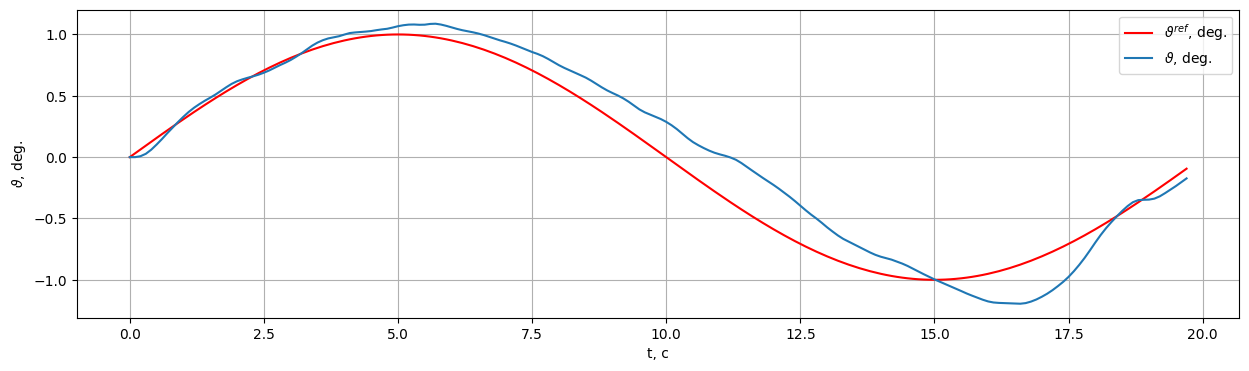

In [19]:
env.unwrapped.model.plot_transient_process('theta', tps, reference_signals[0],to_deg=True , figsize=(15,4))

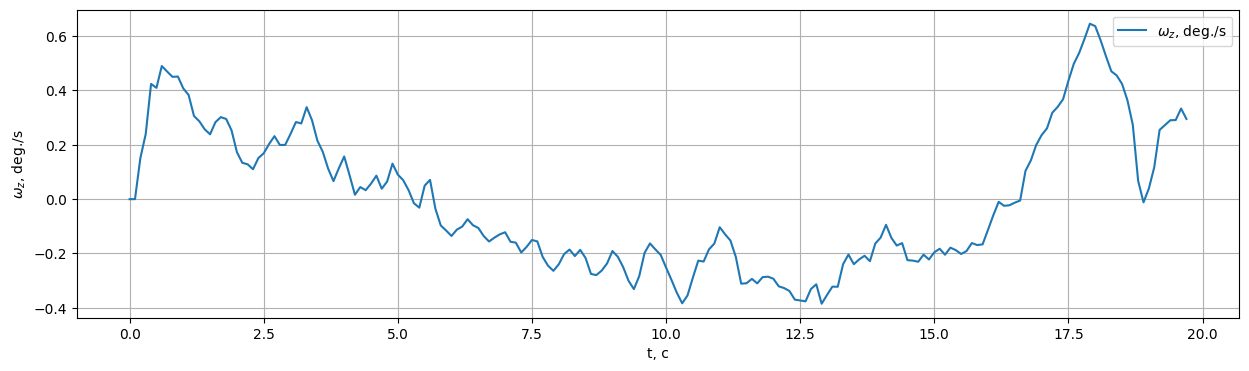

In [20]:
env.unwrapped.model.plot_state(state_name='q', time=tps, to_deg=True, figsize=(15,4))

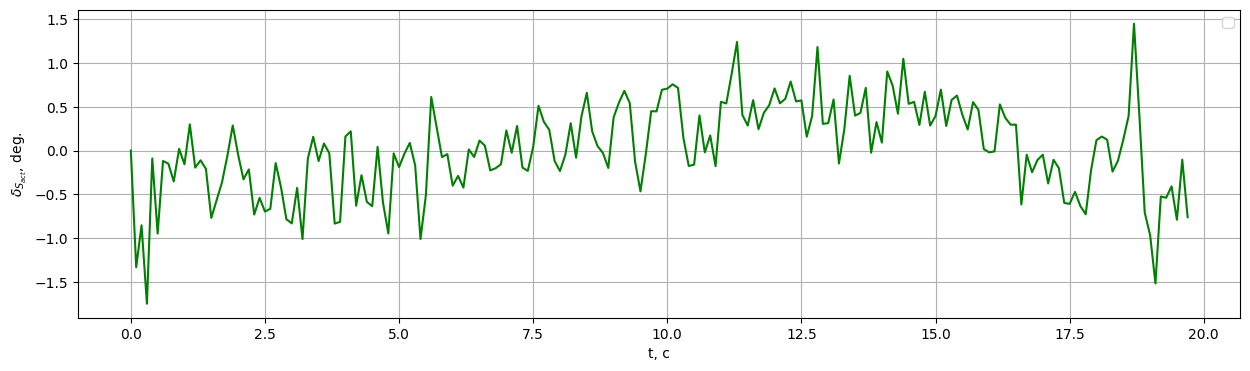

In [21]:
env.unwrapped.model.plot_control(control_name='ele', time=tps, to_deg=True, figsize=(15,4))

In [22]:
agent.save(filepath="./b747_ddpg_grads", include_grads=True)

In [ ]:
# Full run with checkpointing
max_frames = 150_000
max_steps_per_episode = number_time_steps
batch_size = 256

# Optionally resume from checkpoint
ckpt_path = os.path.join("runs", "ddpg_b747_improved", "ckpt_last.pt")
if os.path.isfile(ckpt_path):
    try:
        agent.load(ckpt_path, load_optimizer=True, load_targets=True, load_replay=True, load_noise=True, load_grads=False)
        print("Resumed from:", ckpt_path)
    except Exception as e:
        print("Resume failed:", e)

# Ensure logdir
log_root = os.path.join("runs", "ddpg_b747_improved")
os.makedirs(log_root, exist_ok=True)

try:
    agent.learn(
        max_frames=max_frames,
        max_steps=max_steps_per_episode,
        batch_size=batch_size,
        gamma=0.997,
        soft_tau=3e-3,
        warmup_frames=15_000,
        updates_per_step=2,
        target_value_clip=(-5.0, 5.0),
    )
finally:
    # Save checkpoint
    ckpt_out = os.path.join(log_root, "ckpt_last.pt")
    agent.save(ckpt_out, include_grads=False)
    print("Checkpoint saved to:", ckpt_out)

print("Training finished.")


## TensorBoard

В отдельной ячейке можно запустить отображение логов TensorBoard:

```
%load_ext tensorboard
%tensorboard --logdir runs
```

